In [5]:
import pandas as pd
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
with open('model_cookcash.pkl', 'rb') as f:
    tfidf, tfidf_matrix, df_train = pickle.load(f)

In [7]:
df_test = pd.read_csv('CookCash_Data_Test.csv')

Mencari K dan Threshold terbaik...
Angka terbaik: K = 10, Threshold = 0.4


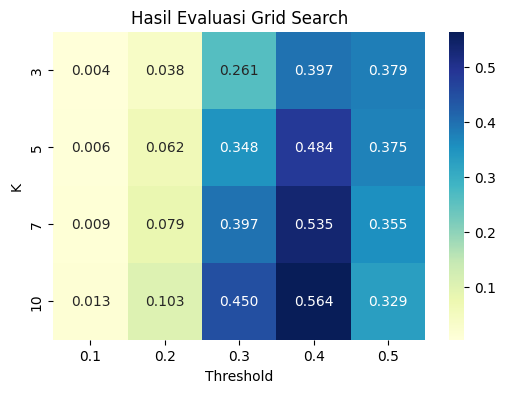

In [8]:
print("Mencari K dan Threshold terbaik...")
k_options = [3, 5, 7, 10]
t_options = [0.1, 0.2, 0.3, 0.4, 0.5]
hasil_simulasi = []

# Pake 100 data aja biar nyarinya cepet
for k in k_options:
    for t in t_options:
        precisions, recalls = [], []
        for index, row in df_test.head(100).iterrows():
            query = str(row['Ingredients Cleaned']) # Sesuaikan nama kolom aslimu
            if not query: continue
            
            vec = tfidf.transform([query])
            sim = cosine_similarity(vec, tfidf_matrix).flatten()
            
            top_k_sim = sim[sim.argsort()[-k:][::-1]]
            relevan = sum(top_k_sim >= t)
            total_relevan = sum(sim >= t)
            
            precisions.append(relevan / k)
            recalls.append(relevan / total_relevan if total_relevan > 0 else 0)
            
        avg_p = np.mean(precisions)
        avg_r = np.mean(recalls)
        f1 = 2 * (avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
        hasil_simulasi.append({'K': k, 'Threshold': t, 'F1-Score': f1})

df_hasil = pd.DataFrame(hasil_simulasi)

# Ambil angka juaranya
best_setting = df_hasil.loc[df_hasil['F1-Score'].idxmax()]
k_terbaik = int(best_setting['K'])
t_terbaik = best_setting['Threshold']

print(f"Angka terbaik: K = {k_terbaik}, Threshold = {t_terbaik}")

# Tampilkan gambar bukti
pivot = df_hasil.pivot(index='K', columns='Threshold', values='F1-Score')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Hasil Evaluasi Grid Search")
plt.show()

In [9]:

K = k_terbaik
threshold = t_terbaik

precision_scores = []
recall_scores = []

for index, row in df_test.iterrows():
    query = row['Ingredients Cleaned']
    
    # Vektor query
    query_vec = tfidf.transform([query])
    
    # Cosine similarity ke semua train
    similarity = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Ambil top-K indeks
    top_k_idx = similarity.argsort()[-K:][::-1]
    top_k_sim = similarity[top_k_idx]
    
    # --- Relevansi berdasarkan threshold ---
    # Rekomendasi relevan jika similarity >= threshold
    relevan = sum(top_k_sim >= threshold)
    
    # Total dokumen relevan di data train (semua yang similarity terhadap query >= threshold)
    total_relevan = sum(similarity >= threshold)
    
    # Precision@K
    precision = relevan / K
    
    # Recall@K
    recall = relevan / total_relevan if total_relevan > 0 else 0
    
    precision_scores.append(precision)
    recall_scores.append(recall)

In [10]:
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)

print(f"Precision@{K} (threshold={threshold}): {avg_precision:.3f}")
print(f"Recall@{K}   (threshold={threshold}): {avg_recall:.3f}")

Precision@10 (threshold=0.4): 0.636
Recall@10   (threshold=0.4): 0.593


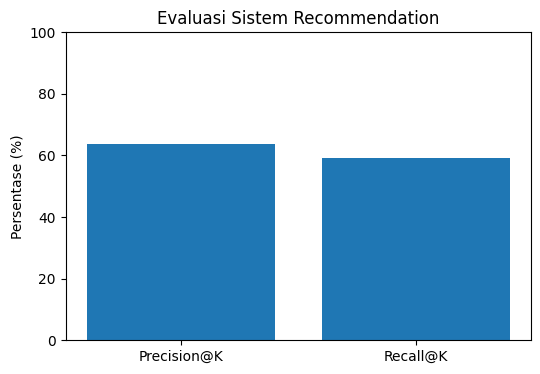

In [11]:
metrics = ['Precision@K', 'Recall@K']
values = [avg_precision * 100, avg_recall * 100]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.title('Evaluasi Sistem Recommendation')
plt.ylabel('Persentase (%)')
plt.ylim(0,100)

plt.show()

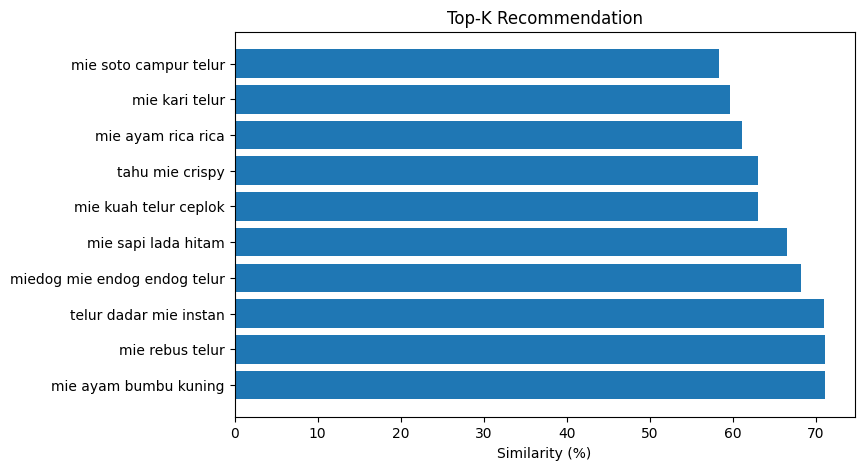

In [12]:
query = "telur mie bawang"

query_vec = tfidf.transform([query])

similarity = cosine_similarity(query_vec, tfidf_matrix).flatten()

top_k_idx = similarity.argsort()[-K:][::-1]

top_scores = similarity[top_k_idx] * 100

top_recipes = df_train.iloc[top_k_idx]['Title Cleaned']

plt.figure(figsize=(8,5))
plt.barh(top_recipes, top_scores)

plt.xlabel('Similarity (%)')
plt.title('Top-K Recommendation')

plt.show()